5.1 Data Cleaning & Missing Value Strategy

In [1]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


1. Kiểm tra kích thước, cấu trúc & kiểu dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Load master dataset
df = pd.read_csv('../data/final/master_dataset.csv')

print("Số dòng, số cột:", df.shape)
print("\nThông tin dữ liệu")
print(df.info())

Số dòng, số cột: (10000, 39)

Thông tin dữ liệu
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10000 non-null  str    
 1   Transaction_Date    10000 non-null  str    
 2   Customer_ID         10000 non-null  str    
 3   Gender              10000 non-null  str    
 4   Age                 10000 non-null  int64  
 5   City                10000 non-null  str    
 6   Product_ID          10000 non-null  int64  
 7   Product_Name        10000 non-null  str    
 8   Category            10000 non-null  str    
 9   Brand               10000 non-null  str    
 10  Quantity            10000 non-null  int64  
 11  Unit_Price_VND      10000 non-null  int64  
 12  Revenue             10000 non-null  int64  
 13  Source_Currency     10000 non-null  str    
 14  Rating              10000 non-null  int64  
 15  Customer_Review  

Đánh giá số lượng và tỷ lệ Missing Values của từng cột.

In [4]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percentage (%)': (df.isna().sum() / len(df)) * 100
}).query('Missing_Count > 0').sort_values(by='Missing_Count', ascending=False)

print("THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES)")
print(missing_summary)

THỐNG KÊ GIÁ TRỊ THIẾU (MISSING VALUES)
                  Missing_Count  Missing_Percentage (%)
avg_rating                 8178                   81.78
reviews_count              8178                   81.78
product_type               8178                   81.78
is_for_sale                8178                   81.78
availability               8178                   81.78
category_2                 8178                   81.78
category_3                 8178                   81.78
manufacturer               8178                   81.78
quantity_sold              1822                   18.22
review_count               1822                   18.22
rating_average             1822                   18.22
current_seller             1822                   18.22
fulfillment_type           1822                   18.22
date_created               1822                   18.22
number_of_images           1822                   18.22
favourite_count            1822                   18.22
has_vide

Trực quan hóa Missing Values bằng thư viện missingno.

<Figure size 1200x600 with 0 Axes>

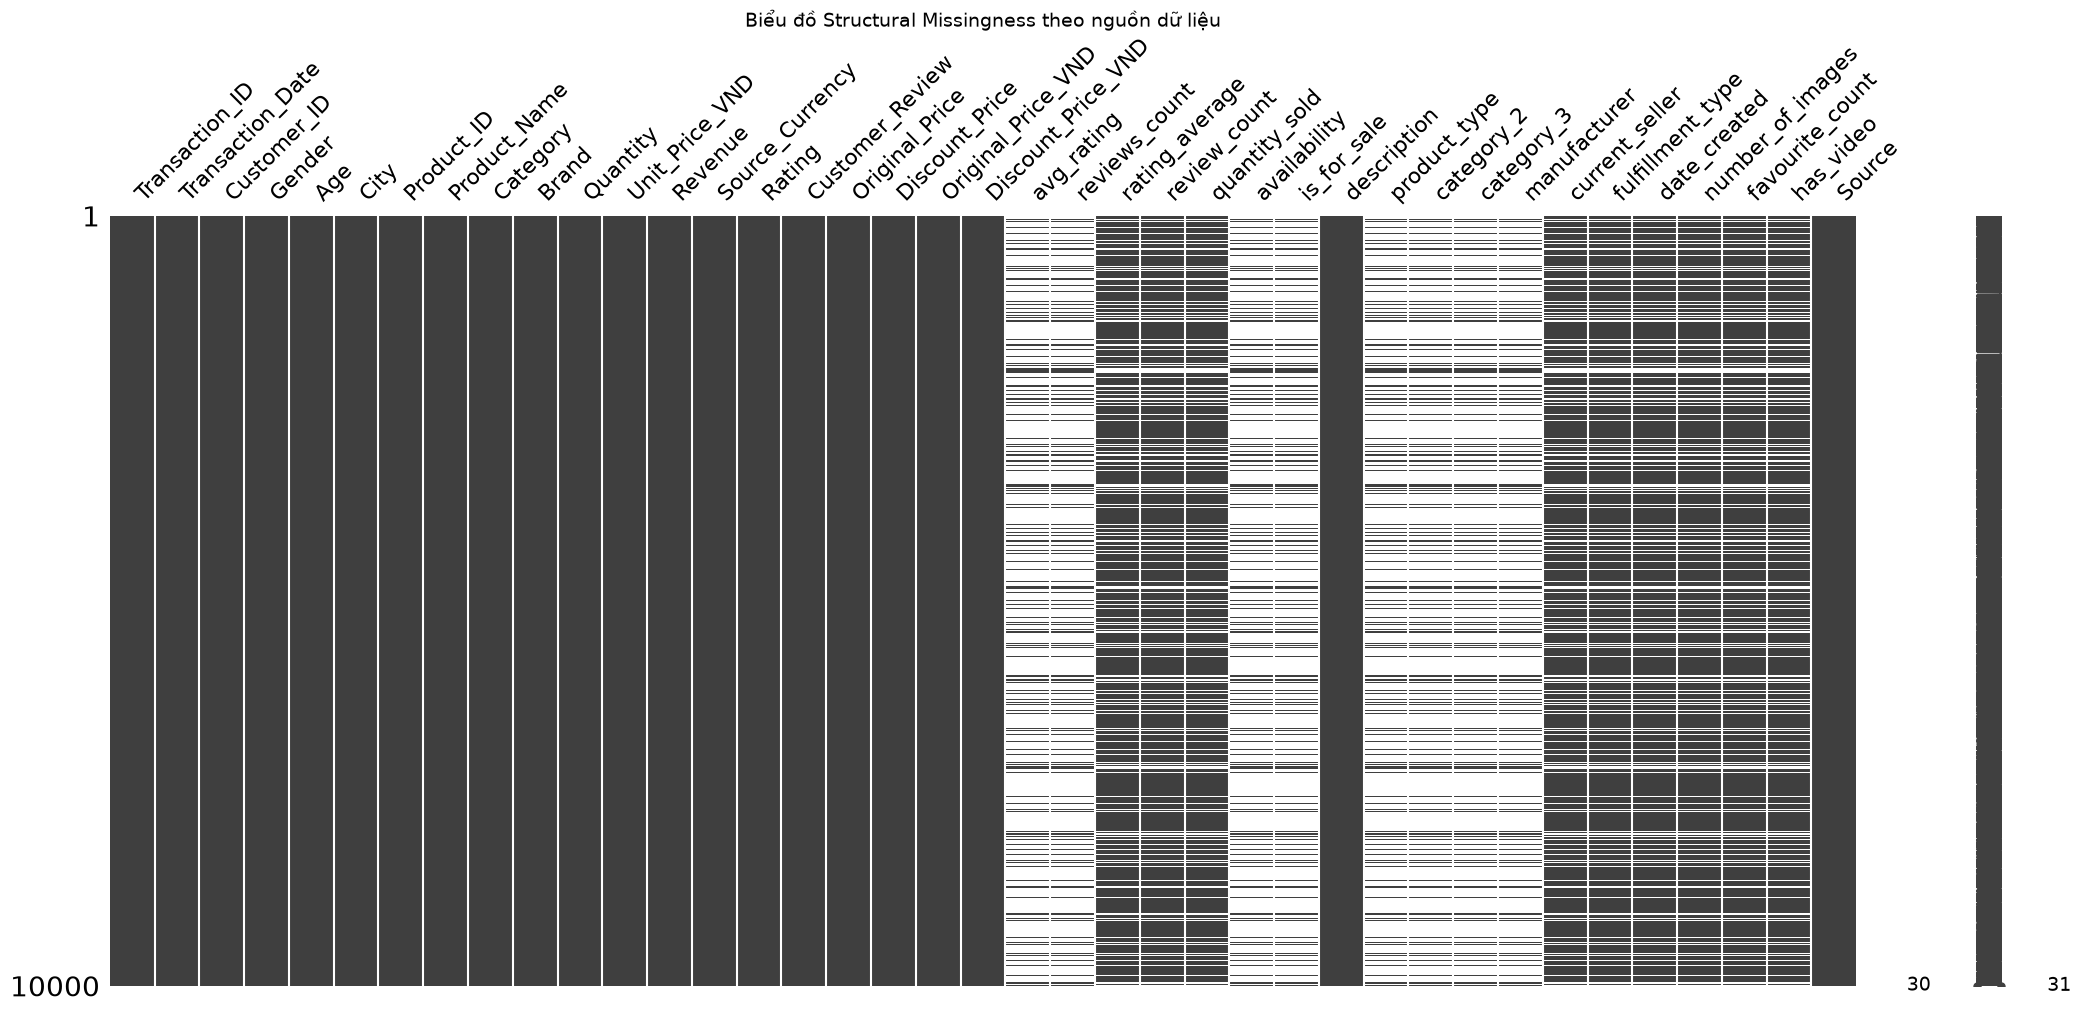

In [5]:
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Biểu đồ Structural Missingness theo nguồn dữ liệu", fontsize=14)
plt.show()

Phân tích cơ chế thiếu dữ liệu (MCAR / MAR / MNAR).

Dựa trên kết quả phân tích hệ thống, cơ chế khuyết dữ liệu của tập dữ liệu này thuộc dạng Missing by Design / Structural Missingness (Khuyết do cấu trúc tích hợp), xuất phát từ bản chất hợp nhất hai nguồn dữ liệu không đồng nhất:

Tập cột thiếu 8.178 dòng (81,78%): Gồm avg_rating, reviews_count, availability, is_for_sale, product_type, category_2, category_3, manufacturer.

Lý do: Các thuộc tính này thuộc về cấu trúc dữ liệu của Tesco UK. Do đó, toàn bộ 8.178 giao dịch xuất phát từ dữ liệu Tiki VN hoàn toàn không chứa các thuộc tính này.

Tập cột thiếu 1.822 dòng (18,22%): Gồm rating_average, review_count, quantity_sold, current_seller, fulfillment_type, date_created, number_of_images, favourite_count, has_video.

Lý do: Các thuộc tính này thuộc về cấu trúc Schema của sàn Tiki VN. Do đó, 1.822 giao dịch xuất phát từ Tesco UK bị khuyết hoàn toàn các trường thông tin này.

Quyết định xử lý: Không sử dụng phương pháp loại bỏ dòng dropna(), vì việc loại bỏ dữ liệu thiếu theo cấu trúc này sẽ dẫn đến việc xóa sạch toàn bộ 10.000 dòng dữ liệu (100% tập dữ liệu). Do đó, phương pháp điền thế thích hợp (Imputation theo từng nhóm đặc trưng nguồn) là bắt buộc.

Lựa chọn phương pháp xử lý Imputation phù hợp (Mean, Median, Mode, Unknown). Giải thích rõ lý do nếu dùng dropna().

In [7]:
# Sao chép dataframe trước khi điền
df_cleaned = df.copy()

# 1. Giữ nguyên dạng số cho rating_average,
#    điền missing theo median của Category
#    (nếu thiếu thì điền median chung)
if 'rating_average' in df_cleaned.columns:
    df_cleaned['rating_average'] = (
        df_cleaned.groupby('Category')['rating_average']
        .transform(lambda x: x.fillna(x.median()))
    )

    df_cleaned['rating_average'] = (
        df_cleaned['rating_average']
        .fillna(df_cleaned['rating_average'].median())
    )

# 2. Xử lý date_created
if 'date_created' in df_cleaned.columns:
    df_cleaned['date_created'] = pd.to_datetime(
        df_cleaned['date_created'],
        errors='coerce'
    )

    # Điền NaT bằng Transaction_Date nếu có
    if 'Transaction_Date' in df_cleaned.columns:
        df_cleaned['date_created'] = (
            df_cleaned['date_created'].fillna(
                pd.to_datetime(
                    df_cleaned['Transaction_Date'],
                    errors='coerce'
                )
            )
        )

# 3. Các cột định lượng khác
num_cols_to_fill_zero = [
    'review_count',
    'reviews_count',
    'quantity_sold',
    'favourite_count',
    'number_of_images'
]

for col in num_cols_to_fill_zero:
    if col in df_cleaned.columns:
        df_cleaned[col] = (
            pd.to_numeric(
                df_cleaned[col],
                errors='coerce'
            ).fillna(0)
        )

# 4. Các cột định tính
cat_cols_structural = [
    'category_2',
    'category_3',
    'manufacturer',
    'current_seller',
    'fulfillment_type',
    'product_type',
    'availability'
]

for col in cat_cols_structural:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna(
            'Not Applicable'
        )

# 5. Cột Boolean/Binary
bool_cols = [
    'is_for_sale',
    'has_video'
]

for col in bool_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].fillna(False)

print("Kiểm tra missing values sau khi Imputation:")
print(
    df_cleaned.isna().sum()[
        df_cleaned.isna().sum() > 0
    ]
)

Kiểm tra missing values sau khi Imputation:
avg_rating    8178
dtype: int64


Lưu ý: avg_rating có 8,178 giá trị thiếu do đây là thuộc tính chỉ tồn tại trong nguồn Tesco. Đây là missing có tính cấu trúc (structural missingness), không phải dữ liệu bị thiếu ngẫu nhiên. Vì vậy không thực hiện thay thế bằng 0 hoặc giá trị thống kê để tránh làm sai ý nghĩa dữ liệu.

So sánh phân phối dữ liệu Before / After Imputation

In [9]:
import IPython.display as display
import pandas as pd

cat_missing_cols = [
    'availability',
    'is_for_sale',
    'product_type',
    'category_2',
    'category_3',
    'manufacturer',
    'current_seller',
    'fulfillment_type',
    'has_video',
    'avg_rating',
    'reviews_count',
]

num_missing_cols = [
    'rating_average',
    'review_count',
    'quantity_sold',
    'number_of_images',
    'favourite_count',
]

#SO SÁNH CỘT ĐỊNH LƯỢNG 

print('=' * 90)
print('SO SÁNH CÁC CỘT ĐỊNH LƯỢNG')
print('=' * 90)

df_num_before = df[num_missing_cols].apply(pd.to_numeric, errors='coerce')
df_num_after = df_cleaned[num_missing_cols].apply(
    pd.to_numeric, errors='coerce'
)

print('\n---> TRƯỚC')
display.display(df_num_before.describe().round(2).T)

print('\n---> SAU')
display.display(df_num_after.describe().round(2).T)



#SO SÁNH CỘT ĐỊNH TÍNH

print('\n' + '=' * 90)
print('SO SÁNH CÁC CỘT ĐỊNH TÍNH')
print('=' * 90)

for col in cat_missing_cols:
    if col in df.columns:
        # Chuẩn hóa chuỗi và đánh dấu rõ ô Missing trước khi đếm
        s_before = df[col].fillna('<Missing / NaN>').astype(str)
        s_after = df_cleaned[col].astype(str)

        # Tạo 2 bảng tần suất độc lập
        df_before_stats = pd.DataFrame({
            'Count (Before)': s_before.value_counts(),
            '% (Before)': (s_before.value_counts(normalize=True) * 100).round(2),
        })

        df_after_stats = pd.DataFrame({
            'Count (After)': s_after.value_counts(),
            '% (After)': (s_after.value_counts(normalize=True) * 100).round(2),
        })

        # Ghép 2 bảng bằng pd.concat theo cột (axis=1) để tránh hoàn toàn lỗi Index
        df_vc_compare = pd.concat(
            [df_before_stats, df_after_stats], axis=1
        ).fillna(0)

        # Sắp xếp danh mục theo số lượng ở tập After giảm dần
        df_vc_compare = df_vc_compare.sort_values(
            by='Count (After)', ascending=False
        )

        print(f"\n--->Cột: '{col}'")
        display.display(df_vc_compare.head(10))

SO SÁNH CÁC CỘT ĐỊNH LƯỢNG

---> TRƯỚC


,count,mean,std,min,25%,50%,75%,max
rating_average,8178.0,1.49,2.15,0.0,0.0,0.0,4.2,5.0
review_count,8178.0,4.29,21.93,0.0,0.0,0.0,1.0,525.0
quantity_sold,8178.0,22.81,108.88,0.0,0.0,1.0,6.0,2742.0
number_of_images,8178.0,6.13,3.56,1.0,3.0,6.0,9.0,41.0
favourite_count,8178.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0



---> SAU


,count,mean,std,min,25%,50%,75%,max
rating_average,10000.0,1.22,2.02,0.0,0.0,0.0,3.4,5.0
review_count,10000.0,3.51,19.90,0.0,0.0,0.0,1.0,525.0
quantity_sold,10000.0,18.65,98.85,0.0,0.0,0.0,4.0,2742.0
number_of_images,10000.0,5.02,4.00,0.0,1.0,5.0,8.0,41.0
favourite_count,10000.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0



SO SÁNH CÁC CỘT ĐỊNH TÍNH

--->Cột: 'availability'


...

,Count (Before),% (Before),Count (After),% (After)
has_video,,,,
False,7284,72.84,9106.0,91.06
True,894,8.94,894.0,8.94
<Missing / NaN>,1822,18.22,0.0,0.00



--->Cột: 'avg_rating'


,Count (Before),% (Before),Count (After),% (After)
avg_rating,,,,
\N,1822,18.22,1822.0,100.0
<Missing / NaN>,8178,81.78,0.0,0.0



--->Cột: 'reviews_count'


,Count (Before),% (Before),Count (After),% (After)
reviews_count,,,,
0.0,0.0,0.00,10000.0,100.0
<Missing / NaN>,8178.0,81.78,0.0,0.0
\N,1822.0,18.22,0.0,0.0


Đang vẽ biểu đồ cho 6 cột định lượng...


C:\Users\Ha Xuan Khoa\AppData\Local\Temp\ipykernel_3644\2390080366.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


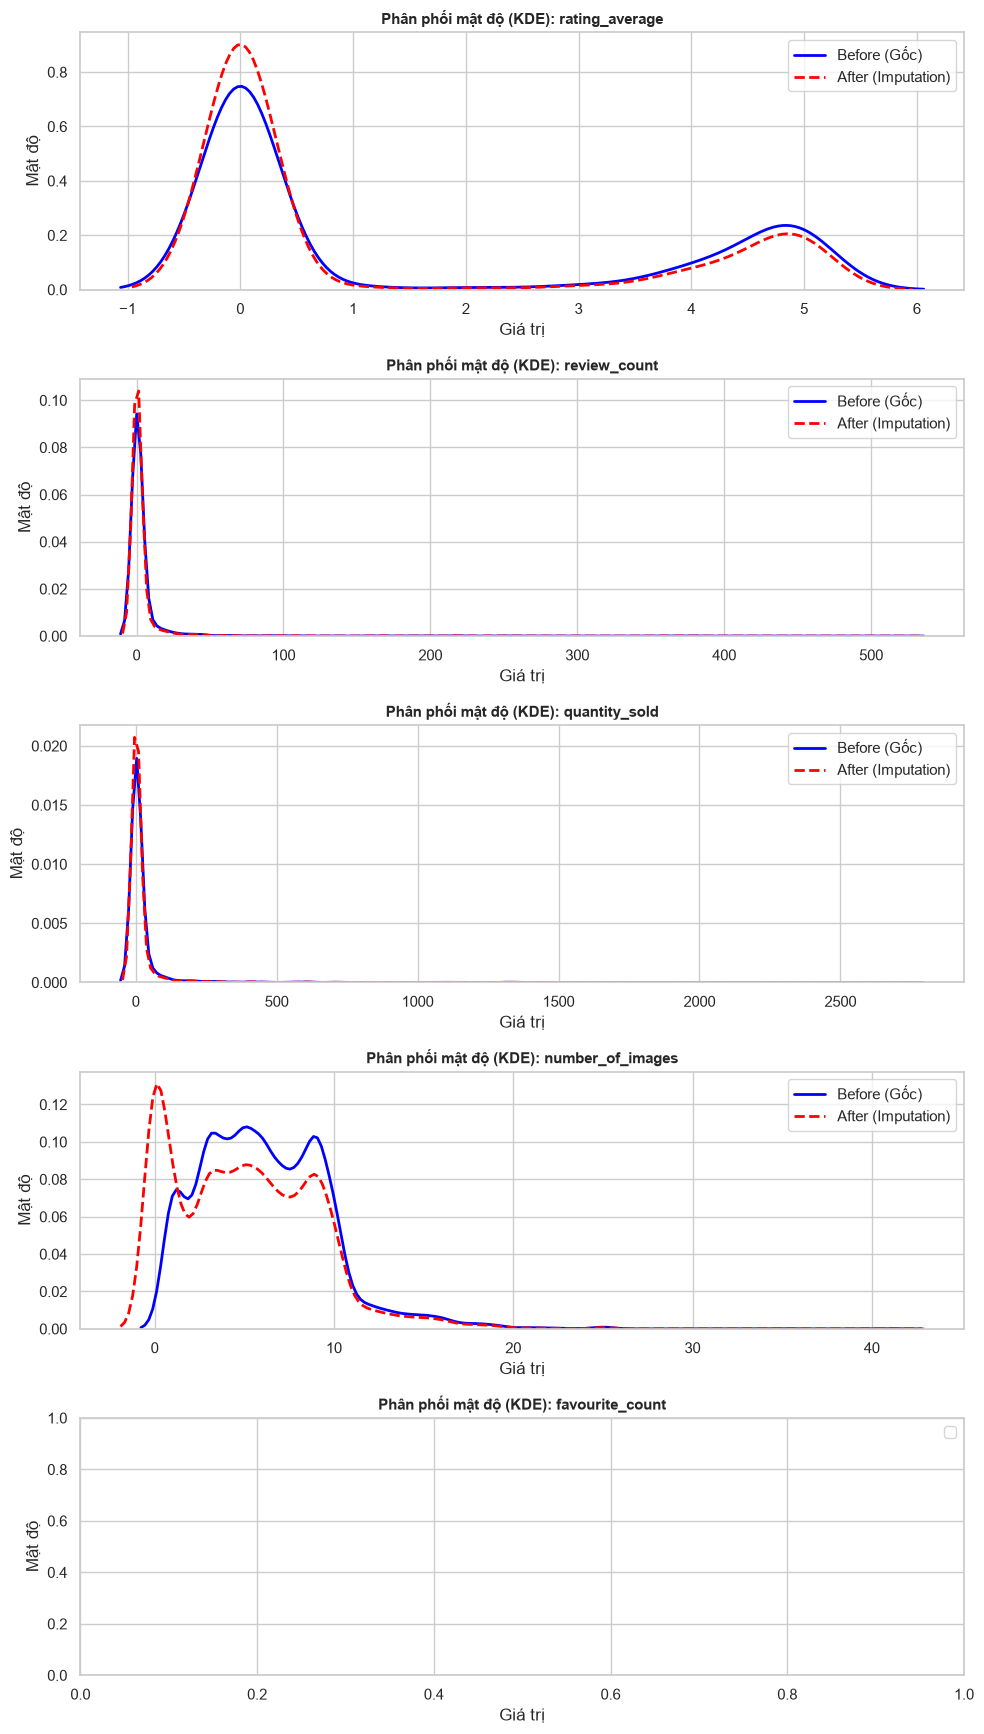

Đang vẽ biểu đồ cho 11 cột định tính...


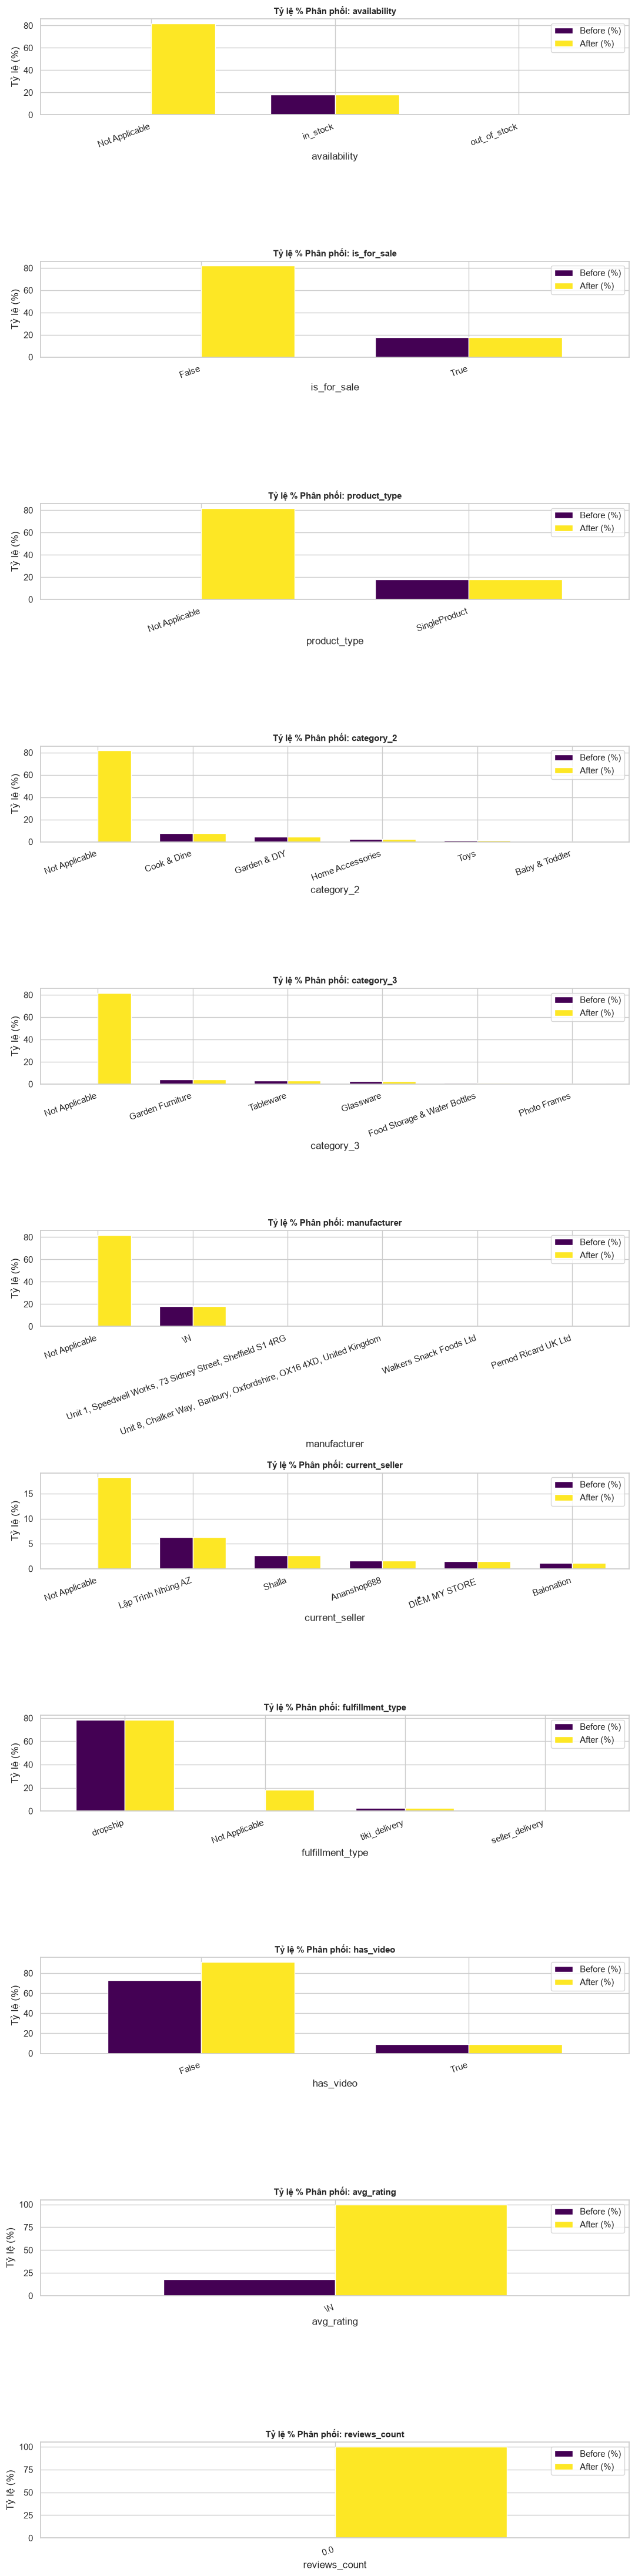

In [10]:
# ==============================================================================
# BIỂU ĐỒ SO SÁNH PHÂN PHỐI BEFORE / AFTER 
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

# ------------------------------------------------------------------------------
# 1. BIỂU ĐỒ CHO TẤT CẢ 6 CỘT ĐỊNH LƯỢNG (NUMERICAL)
# ------------------------------------------------------------------------------
print('Đang vẽ biểu đồ cho 6 cột định lượng...')
fig, axes = plt.subplots(
    len(num_missing_cols), 1, figsize=(10, 3.5 * len(num_missing_cols))
)

for i, col in enumerate(num_missing_cols):
    if col in df.columns:
        s_before = pd.to_numeric(df[col], errors='coerce').dropna()
        s_after = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0)

        sns.kdeplot(
            s_before,
            ax=axes[i],
            label='Before (Gốc)',
            color='blue',
            linewidth=2,
            warn_singular=False
        )
        sns.kdeplot(
            s_after,
            ax=axes[i],
            label='After (Imputation)',
            color='red',
            linestyle='--',
            linewidth=2,
            warn_singular=False
        )

        axes[i].set_title(
            f'Phân phối mật độ (KDE): {col}', fontsize=11, fontweight='bold'
        )
        axes[i].set_xlabel('Giá trị')
        axes[i].set_ylabel('Mật độ')
        axes[i].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# 2. BIỂU ĐỒ CHO TẤT CẢ 11 CỘT ĐỊNH TÍNH (CATEGORICAL)
# ------------------------------------------------------------------------------
print('Đang vẽ biểu đồ cho 11 cột định tính...')
fig, axes = plt.subplots(
    len(cat_missing_cols), 1, figsize=(11, 4 * len(cat_missing_cols))
)

for i, col in enumerate(cat_missing_cols):
    if col in df.columns:
        # Lấy top 6 giá trị xuất hiện nhiều nhất ở tập After để vẽ
        top_cats = df_cleaned[col].astype(str).value_counts().head(6).index

        df_plot_before = (
            df[col]
            .fillna('<Missing>')
            .astype(str)
            .value_counts(normalize=True)
            .reindex(top_cats, fill_value=0)
            * 100
        )
        df_plot_after = (
            df_cleaned[col]
            .astype(str)
            .value_counts(normalize=True)
            .reindex(top_cats, fill_value=0)
            * 100
        )

        plot_data = pd.DataFrame(
            {'Before (%)': df_plot_before, 'After (%)': df_plot_after}
        )

        plot_data.plot(kind='bar', ax=axes[i], colormap='viridis', width=0.7)
        axes[i].set_title(
            f'Tỷ lệ % Phân phối: {col}', fontsize=11, fontweight='bold'
        )
        axes[i].set_ylabel('Tỷ lệ (%)')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=20, ha='right')
        axes[i].legend()

plt.tight_layout()
plt.show()

Phát hiện Outliers bằng IQR / Z-score và xử lý (Drop/Clip) tùy đặc điểm biến.

In [11]:

df_cleaned = df.copy()
# 1. Định nghĩa hàm tính toán chỉ số Outliers bằng IQR và Z-Score (Chỉ dùng để khảo sát)
def detect_outliers_summary(df, cols):
    outlier_info = []
    for col in cols:
        if not np.issubdtype(df[col].dtype, np.number):
            continue
        
        # IQR Method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_iqr = Q1 - 1.5 * IQR
        upper_iqr = Q3 + 1.5 * IQR
        iqr_outliers = df[(df[col] < lower_iqr) | (df[col] > upper_iqr)].shape[0]
        
        # Z-Score Method (|Z| > 3)
        mean = df[col].mean()
        std = df[col].std()
        if std > 0:
            z_scores = (df[col] - mean) / std
            z_outliers = (np.abs(z_scores) > 3).sum()
        else:
            z_outliers = 0
            
        outlier_info.append({
            'Column': col,
            'IQR_Lower_Bound': lower_iqr,
            'IQR_Upper_Bound': upper_iqr,
            'IQR_Outliers_Count': iqr_outliers,
            'IQR_Outliers_Ratio (%)': round(iqr_outliers / len(df) * 100, 2),
            'ZScore_Outliers_Count': z_outliers,
            'ZScore_Outliers_Ratio (%)': round(z_outliers / len(df) * 100, 2)
        })
    return pd.DataFrame(outlier_info)

# Các cột số chính cần phân tích
numeric_cols = [
    'Age', 'Quantity', 'Unit_Price_VND', 'Revenue', 
    'Original_Price_VND', 'Discount_Price_VND', 
    'rating_average', 'review_count', 'quantity_sold'
]

print("=== THỐNG KÊ OUTLIERS BẰNG IQR & Z-SCORE ===")
outlier_df = detect_outliers_summary(
    df_cleaned,
    [c for c in numeric_cols if c in df_cleaned.columns]
)
print(outlier_df.to_string(index=False))

# ------------------------------------------------------------------------------
# 2. XỬ LÝ OUTLIER DỰA TRÊN BẢN CHẤT LOGIC CỦA TỪNG BIẾN (DOMAIN KNOWLEDGE)
# ------------------------------------------------------------------------------

initial_shape = df_cleaned.shape
print(f"\nKích thước dữ liệu ban đầu: {initial_shape}")

# --- TRƯỜNG HỢP 1: Xóa/Sửa các giá trị VI PHẠM LOGIC (Sai dữ liệu thực tế) ---

# a. Độ tuổi (Age): Tuổi phải nằm trong khoảng hợp lý (ví dụ: 10 đến 100 tuổi)
if 'Age' in df_cleaned.columns:
    invalid_age = df_cleaned[
        (df_cleaned['Age'] < 10) | (df_cleaned['Age'] > 100)
    ]
    print(f"Số dòng vi phạm logic Tuổi (<10 hoặc >100): {len(invalid_age)}")

    df_cleaned = df_cleaned[
        (df_cleaned['Age'] >= 10) & (df_cleaned['Age'] <= 100)
    ]

# b. Giá bán & Doanh thu (Unit_Price_VND, Revenue, Quantity): Không thể âm hoặc bằng 0 trong giao dịch hợp lệ
invalid_financials = df_cleaned[
    (df_cleaned['Quantity'] <= 0) |
    (df_cleaned['Unit_Price_VND'] < 0) |
    (df_cleaned['Revenue'] < 0)
]

print(
    f"Số dòng vi phạm logic Giá/Số lượng/Doanh thu (<= 0): "
    f"{len(invalid_financials)}"
)

df_cleaned = df_cleaned[
    (df_cleaned['Quantity'] > 0) &
    (df_cleaned['Unit_Price_VND'] >= 0) &
    (df_cleaned['Revenue'] >= 0)
]

# c. Đánh giá (Rating / rating_average): Phải nằm trong thang điểm 1 - 5 (hoặc 0 - 5)
if 'rating_average' in df_cleaned.columns:
    invalid_rating = df_cleaned[
        (df_cleaned['rating_average'] < 0) |
        (df_cleaned['rating_average'] > 5)
    ]

    print(
        f"Số dòng vi phạm logic Rating (<0 hoặc >5): "
        f"{len(invalid_rating)}"
    )

    df_cleaned = df_cleaned[
        df_cleaned['rating_average'].isna() |
        (
            (df_cleaned['rating_average'] >= 0) &
            (df_cleaned['rating_average'] <= 5)
        )
    ]

# --- TRƯỜNG HỢP 2: Giữ lại Outliers HỢP LỆ (Lượng mua lớn, Giá trị cao thực tế) ---
# Đối với các biến như Quantity, Revenue, Discount_Price_VND, quantity_sold:
# Các giá trị nằm ngoài vạch IQR/Z-score nhưng KHÔNG vi phạm logic ở trên sẽ ĐƯỢC GIỮ NGUYÊN 
# vì đây thể hiện hành vi mua sắm thực tế (khách hàng VIP, mua sỉ, khuyến mãi khủng).


# --- TRƯỜNG HỢP 3: Giới hạn (Clip/Winsorize) có kiểm soát đối với các biến phân phối lệch cực đoan (Nếu cần thiết cho mô hình ML) ---
# Ví dụ: Chỉ Capping/Clipping ở percentile 99.9% thay vì 1.5*IQR để tránh làm biến dạng dữ liệu quá nhiều.

cols_to_cap = ['Revenue', 'Quantity']

for col in cols_to_cap:
    if col in df_cleaned.columns:
        upper_limit = df_cleaned[col].quantile(0.999)

        outliers_capped = (
            df_cleaned[col] > upper_limit
        ).sum()

        df_cleaned[col] = np.where(
            df_cleaned[col] > upper_limit,
            upper_limit,
            df_cleaned[col]
        )

        print(
            f"Đã Clip cột '{col}' tại ngưỡng 99.9% "
            f"({upper_limit}): {outliers_capped} giá trị được điều chỉnh."
        )

# Summary kết quả sau xử lý
print(f"\nKích thước dữ liệu sau khi làm sạch Outlier: {df_cleaned.shape}")

print(
    f"Số dòng đã bị xoá (loại bỏ lỗi logic): "
    f"{initial_shape[0] - df_cleaned.shape[0]} dòng "
    f"({(initial_shape[0] - df_cleaned.shape[0]) / initial_shape[0] * 100:.2f}%)"
)

=== THỐNG KÊ OUTLIERS BẰNG IQR & Z-SCORE ===
            Column  IQR_Lower_Bound  IQR_Upper_Bound  IQR_Outliers_Count  IQR_Outliers_Ratio (%)  ZScore_Outliers_Count  ZScore_Outliers_Ratio (%)
               Age            -7.00            89.00                   0                    0.00                      0                       0.00
          Quantity            -1.00             7.00                   0                    0.00                      0                       0.00
    Unit_Price_VND       -793500.00       1482500.00                1088                   10.88                    191                       1.91
           Revenue      -2435001.25       4485000.75                1053                   10.53                    159                       1.59
Original_Price_VND       -879718.00       1639530.00                1072                   10.72                    185                       1.85
Discount_Price_VND       -793500.00       1482500.00                1088 

# 5.2. Exploratory Data Analysis (EDA) 

In [12]:

# Phân tích Univariate (Thống kê mô tả, phân phối).
# Đảm bảo chúng ta có tập dữ liệu df_cleaned đã được xử lý đầy đủ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Thiết lập giao diện biểu đồ
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Danh sách các biến định lượng (bao gồm cả các biến mới từ Feature Engineering)
key_numeric_cols = [
    'Age', 'Quantity', 'Unit_Price_VND', 'Revenue', 
    'Rating', 'Discount_Ratio', 'product_static_rating'
]
valid_cols = [c for c in key_numeric_cols if c in df_cleaned.columns]

# 3. Thống kê mô tả dạng bảng
print("THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH XUYÊN SUỐT:")
try:
    display(df_cleaned[valid_cols].describe().round(2))
except NameError:
    print(df_cleaned[valid_cols].describe().round(2))

THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ CHÍNH XUYÊN SUỐT:


,Age,Quantity,Unit_Price_VND,Revenue,Rating
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,41.38,3.01,726136.40,2177856.02,3.01
std,13.80,1.41,1743641.39,5646946.89,1.42
min,18.00,1.00,1000.00,1000.00,1.00
25%,29.00,2.00,60000.00,159999.50,2.00
50%,41.00,3.00,275507.50,612500.00,3.00
75%,53.00,4.00,629000.00,1890000.00,4.00
max,65.00,5.00,32324592.00,75079812.11,5.00


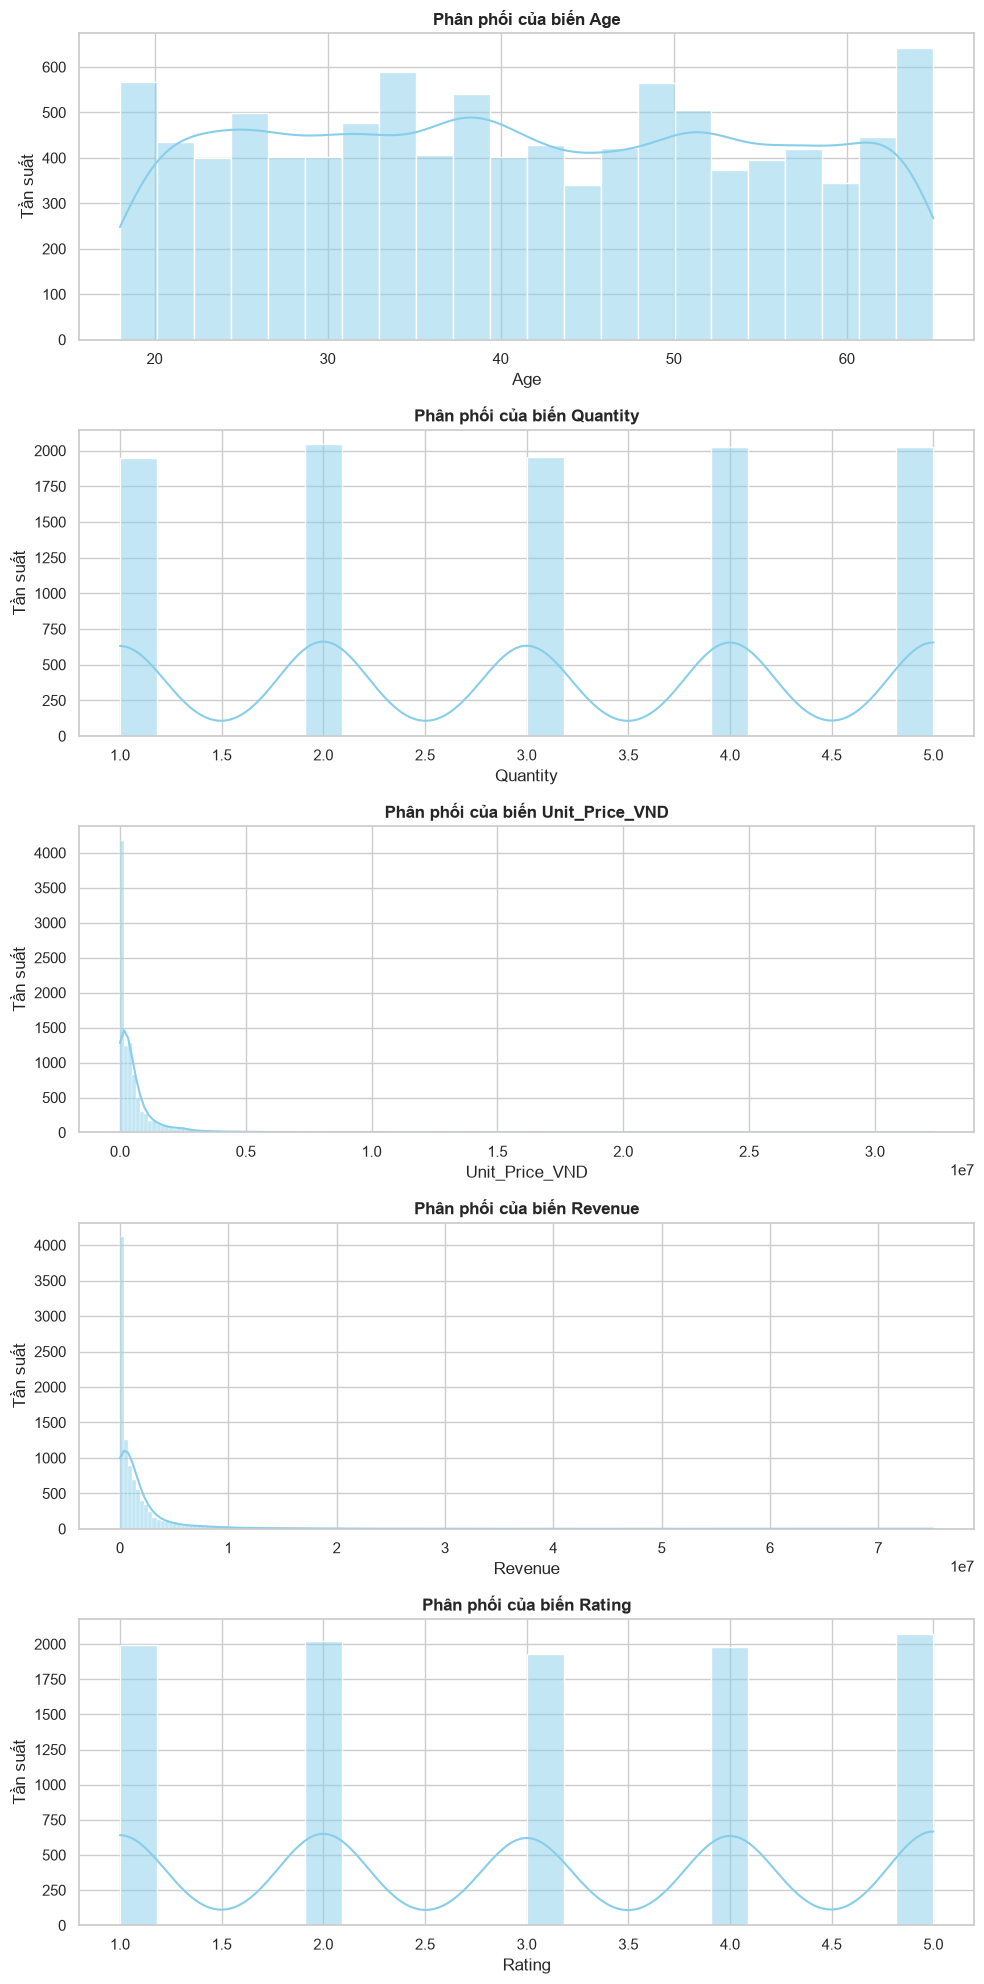

In [13]:
#trực quan hóa phân phối cho từng biến.
fig, axes = plt.subplots(nrows=len(valid_cols), ncols=1, figsize=(10, 4 * len(valid_cols)))
if len(valid_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, valid_cols):
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Phân phối của biến {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

# 1. Tính toán Discount_Ratio dựa trên giá VND
# Sử dụng np.where để xử lý an toàn trường hợp Original_Price_VND = 0 (tránh lỗi chia cho 0)
df_cleaned['Discount_Ratio'] = np.where(
    df_cleaned['Original_Price_VND'] > 0,
    (df_cleaned['Original_Price_VND'] - df_cleaned['Discount_Price_VND'])
    / df_cleaned['Original_Price_VND'],
    0
)

# 2. Phân loại và chuẩn hóa Rating
# Ép kiểu avg_rating (hiện là object) sang dạng số
df_cleaned['avg_rating_num'] = pd.to_numeric(
    df_cleaned['avg_rating'],
    errors='coerce'
)

# Gom chung 2 cột static rating lại thành 1 feature đại diện cho danh tiếng chung của sản phẩm
df_cleaned['product_static_rating'] = (
    df_cleaned['rating_average']
    .fillna(df_cleaned['avg_rating_num'])
)


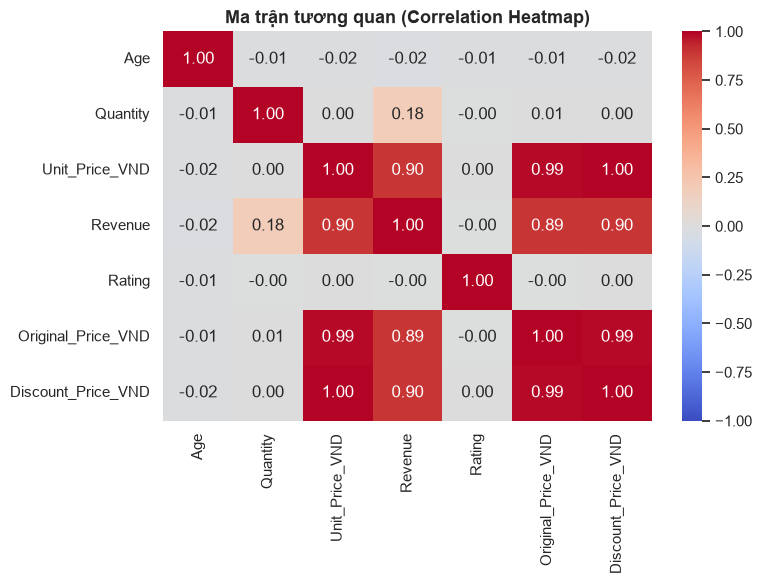

In [15]:
##Phân tích Bivariate/Multivariate và ma trận tương quan (Correlation Heatmap).
plt.figure(figsize=[8,6])
num_cols = ['Age','Quantity','Unit_Price_VND','Revenue','Rating','Original_Price_VND', 'Discount_Price_VND']
corr = df_cleaned[num_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan (Correlation Heatmap)', fontsize =13, fontweight='bold')
plt.tight_layout()
plt.show()

# Vẽ các biểu đồ bằng Matplotlib / Seaborn (đầy đủ Title, X/Y labels).

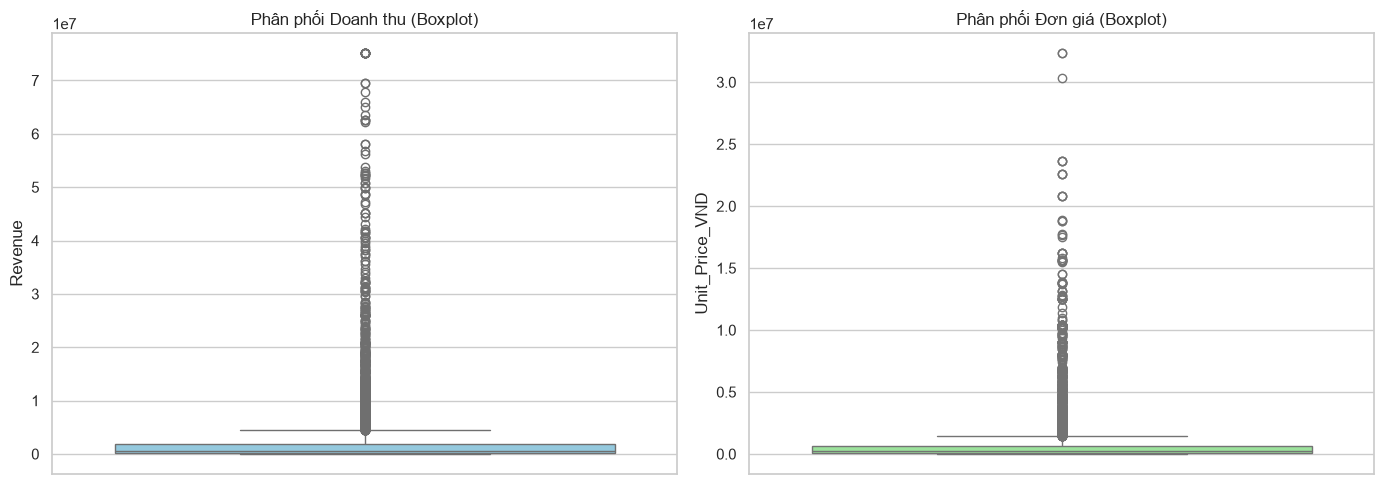

In [16]:
#Biểu đồ 0: Trực quan hóa phân phối giữa Doanh Thu và Đơn Giá.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df_cleaned['Revenue'], ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Doanh thu (Boxplot)')

sns.boxplot(y=df_cleaned['Unit_Price_VND'], ax=axes[1], color='lightgreen')
axes[1].set_title('Phân phối Đơn giá (Boxplot)')
plt.tight_layout()
plt.show()

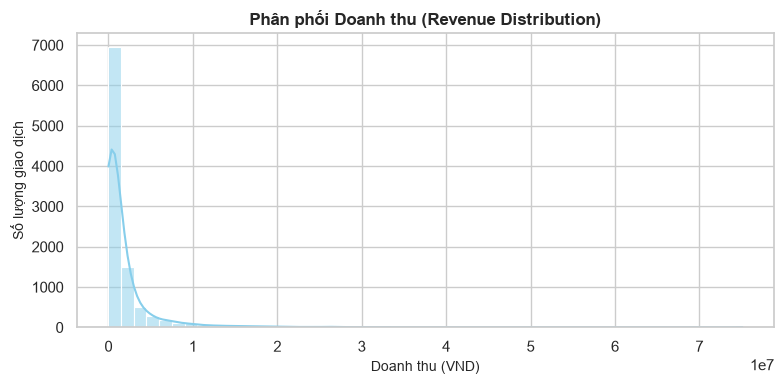

In [17]:
# Biểu đồ 1: Revenue Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['Revenue'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối Doanh thu (Revenue Distribution)', fontsize=12, fontweight='bold')
plt.xlabel('Doanh thu (VND)', fontsize=10)
plt.ylabel('Số lượng giao dịch', fontsize=10)
plt.tight_layout()
plt.show()

# Insight: 
Phân phối doanh thu lệch phải rõ rệt: phần lớn giao dịch có doanh thu ở mức thấp đến trung bình, trong khi một số ít giao dịch có giá trị rất cao kéo dài phần đuôi phân phối. Điều này cho thấy doanh thu giữa các giao dịch có sự phân hóa lớn.

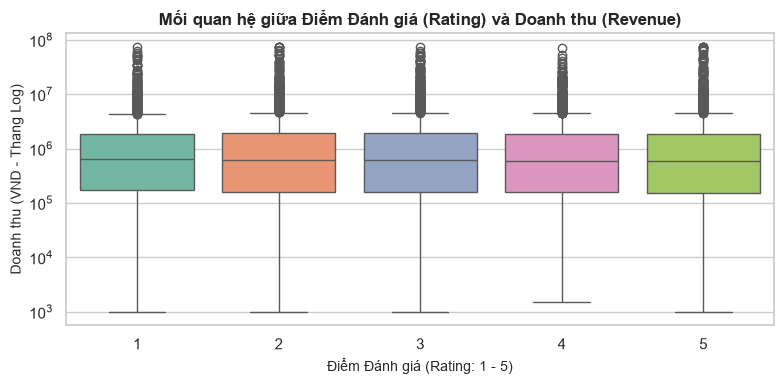

In [18]:
#Biểu đồ 2: Thang đo Logarithm
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_cleaned, x='Rating', y='Revenue', palette='Set2', hue='Rating', legend=False)
plt.yscale('log')
plt.title('Mối quan hệ giữa Điểm Đánh giá (Rating) và Doanh thu (Revenue)', fontsize=12, fontweight='bold')
plt.xlabel('Điểm Đánh giá (Rating: 1 - 5)', fontsize=10)
plt.ylabel('Doanh thu (VND - Thang Log)', fontsize=10)
plt.tight_layout()
plt.show()

# Insight:
* Trung vị Revenue giữa các mức Rating (1–5 sao) không cho thấy khác biệt rõ rệt trong biểu đồ. Pearson r giữa Rating và Revenue xấp xỉ 0; kết quả chỉ mô tả dataset hiện tại.

* Các giao dịch có doanh thu cao xuất hiện ở nhiều mức Rating khác nhau; Rating trong dataset được mô phỏng nên không đại diện trực tiếp cho mức độ hài lòng thực tế.
# Giới hạn diễn giải:
* Hệ số Pearson giữa Rating và Revenue xấp xỉ 0 trong dataset hiện tại.
* Không thể kết luận quan hệ nhân quả từ phân tích tương quan. Rating trong dataset được mô phỏng nên không đại diện trực tiếp cho mức độ hài lòng thực tế của khách hàng.

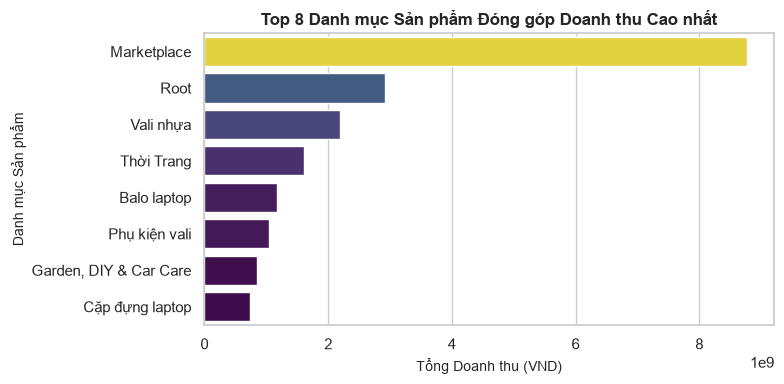

In [19]:
#Biểu đồ 3: Top 8 Danh mục có Tổng Doanh thu Cao nhất
top_cats = df_cleaned.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(8).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=top_cats, x='Revenue', y='Category', palette='viridis', hue='Revenue', legend=False)
plt.title('Top 8 Danh mục Sản phẩm Đóng góp Doanh thu Cao nhất', fontsize=12, fontweight='bold')
plt.xlabel('Tổng Doanh thu (VND)', fontsize=10)
plt.ylabel('Danh mục Sản phẩm', fontsize=10)
plt.tight_layout()
plt.show()

# Insight:
* Tập trung doanh thu: Tổng doanh thu có xu hướng phụ thuộc lớn vào các danh mục ở nhóm đầu, cho thấy vai trò trụ cột của một số ít nhóm ngành hàng trong việc đóng góp vào quy mô dòng tiền chung.

* Sự phân hóa quy mô: Có khoảng cách rõ rệt về giá trị đóng góp giữa các danh mục dẫn đầu so với các danh mục ở nhóm dưới của Top 8.

* Cơ cấu đóng góp: Tổng doanh thu cao ở các danh mục này thường đi kèm với sản lượng tiêu thụ lớn, đơn giá sản phẩm thuộc phân khúc trung-cao, hoặc sự kết hợp của cả hai yếu tố.

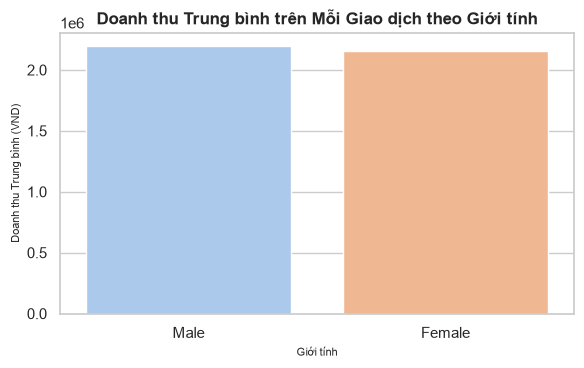

In [20]:
#Biểu đồ 4: So sánh Doanh thu Trung bình theo Giới tính
plt.figure(figsize=(6, 4))
sns.barplot(data=df_cleaned, x='Gender', y='Revenue', estimator=np.mean, errorbar=None, palette='pastel', hue='Gender', legend=False)
plt.title('Doanh thu Trung bình trên Mỗi Giao dịch theo Giới tính', fontsize=12, fontweight='bold')
plt.xlabel('Giới tính', fontsize=8)
plt.ylabel('Doanh thu Trung bình (VND)', fontsize=8)
plt.tight_layout()
plt.show()

# Insight:
* Sự đồng đều về sức chi: Mức chi tiêu trung bình trên mỗi đơn hàng giữa các nhóm giới tính có xu hướng tương đồng, không ghi nhận sự chênh lệch đáng kể.

* Mối liên hệ với giá trị đơn: Yếu tố giới tính chưa cho thấy sự liên hệ rõ rệt với giá trị của một giao dịch đơn lẻ.

* Định hướng phân tích quy mô: Sự khác biệt về tổng doanh thu giữa các nhóm khách hàng (nếu có) thường đi kèm với tần suất mua hàng và quy mô tập khách hàng, thay vì giá trị trung bình trên từng đơn hàng.

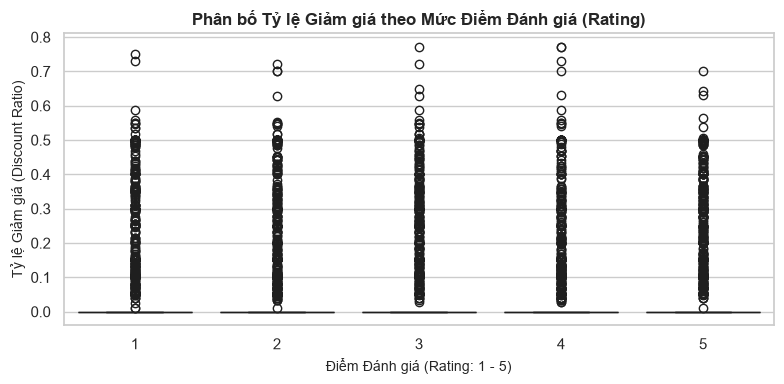

In [21]:
#Biểu đồ 5: Biểu đồ tỷ lệ giảm giá:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_cleaned['Discount_Ratio'] = np.where(
    df_cleaned['Original_Price_VND'] > 0,
    (df_cleaned['Original_Price_VND'] - df_cleaned['Discount_Price_VND']) / df_cleaned['Original_Price_VND'],
    0
)

# Vẽ biểu đồ Boxplot
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df_cleaned,
    x='Rating',
    y='Discount_Ratio',
    palette='Blues_d',
    hue='Rating',
    legend=False
)

plt.title(
    'Phân bố Tỷ lệ Giảm giá theo Mức Điểm Đánh giá (Rating)',
    fontsize=12,
    fontweight='bold'
)
plt.xlabel('Điểm Đánh giá (Rating: 1 - 5)', fontsize=10)
plt.ylabel('Tỷ lệ Giảm giá (Discount Ratio)', fontsize=10)

plt.tight_layout()
plt.show()

# Insight:
* Tỷ lệ giảm giá có phân phối lệch mạnh về 0: phần lớn giao dịch không ghi nhận giảm giá, trong khi một số giao dịch có mức giảm cao, tối đa khoảng 77,2%.

* Khoảng 76,67% giao dịch có Discount_Ratio = 0 và median ở cả 5 mức Rating đều bằng 0. Điều này chỉ mô tả mức giảm giá điển hình; chưa đủ căn cứ để kết luận về tác động của khuyến mãi đến Rating.

* Một số giao dịch có mức giảm cao, tối đa khoảng 77,2%; không suy ra từ đó rằng khuyến mãi làm tăng hoặc giảm sự hài lòng.

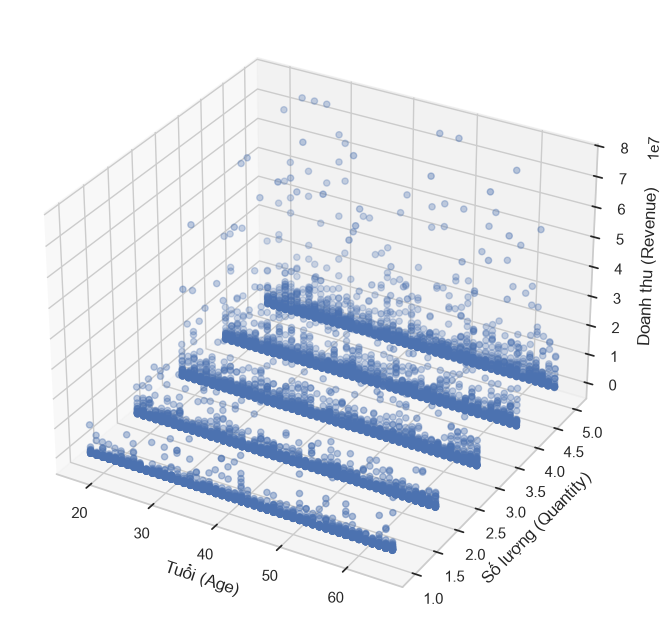

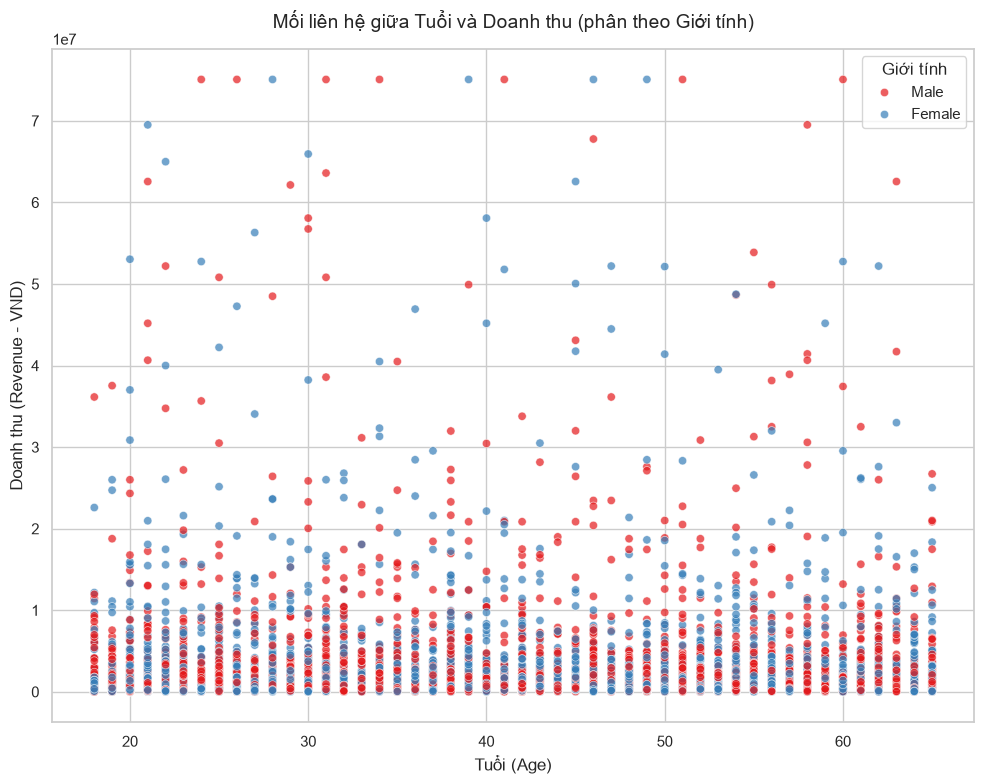

In [22]:
# Biểu đồ đặc biệt: Mối liên hệ giữa Tuổi, Số lượng và Doanh thu
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d") 
ax.scatter(
    xs=df_cleaned['Age'], 
    ys=df_cleaned['Quantity'], 
    zs=df_cleaned['Revenue'],  
    alpha=0.7
)

ax.set_xlabel('Tuổi (Age)')
ax.set_ylabel('Số lượng (Quantity)')
ax.set_zlabel('Doanh thu (Revenue)')
plt.show()

#Biểu đồ khác: 
fig, ax = plt.subplots(figsize=(10, 8))
sns.set_theme(style='whitegrid')
sns.scatterplot(
    data=df_cleaned,
    x='Age',
    y='Revenue',
    hue='Gender', 
    alpha=0.7,    
    palette='Set1',
    ax=ax
)

plt.title('Mối liên hệ giữa Tuổi và Doanh thu (phân theo Giới tính)', fontsize=14, pad=15)
plt.xlabel('Tuổi (Age)', fontsize=12)
plt.ylabel('Doanh thu (Revenue - VND)', fontsize=12)
plt.legend(title='Giới tính')
plt.tight_layout()
plt.show()

# Insight: 
* Biểu đồ 3D Scatter (Age – Quantity – Revenue)
- * Doanh thu có xu hướng tăng khi số lượng sản phẩm trong giao dịch tăng, nhưng mức độ liên hệ không mạnh. Trong khi đó, các giao dịch doanh thu cao xuất hiện ở nhiều độ tuổi khác nhau, cho thấy Age không phải yếu tố nổi bật đối với Revenue trong dữ liệu này.

- * Các giao dịch có doanh thu cao xuất hiện ở nhiều độ tuổi khác nhau; Quantity có mối liên hệ dương nhưng không mạnh với Revenue, do đó chưa thể xem số lượng là yếu tố chính quyết định doanh thu.
* Biểu đồ 2D Scatter (Age vs Revenue phân theo Gender)
- * Phân bố theo Giới tính: Các điểm biểu diễn của Nam và Nữ cho thấy sự đan xen đồng đều, không hình thành các cụm biệt lập theo giới tính hay độ tuổi.

- * Các giao dịch doanh thu cao xuất hiện ở cả hai giới và nhiều nhóm tuổi khác nhau, không cho thấy sự phân tách rõ ràng theo giới tính hoặc độ tuổi.

# Tổng kết insight EDA và hướng phân tích tiếp theo


1. Revenue

Unit_Price_VND có tương quan dương rất mạnh với Revenue (r = 0,8967), còn Quantity có tương quan dương yếu (r = 0,1818). Revenue được tạo ban đầu theo công thức Quantity × Unit_Price_VND; sau đó 10 giá trị Revenue được clip tại percentile 99,9% trong bước làm sạch. Vì vậy, các tương quan này chủ yếu phản ánh cấu trúc tạo dữ liệu, không phải bằng chứng về quan hệ nhân quả hay hành vi mua hàng.

2. Category

Top 8 nhãn Category theo tổng Revenue chiếm khoảng 88,59% tổng Revenue. Kết quả cần được diễn giải thận trọng vì Category giữa Tesco và Tiki chưa được chuẩn hóa về cùng cấp phân loại.

3. Rating

Rating gần như không có tương quan tuyến tính với Revenue (Pearson r = -0,0028). Kết quả chỉ mô tả mối quan hệ trên dataset hiện tại và không đủ để kết luận về mức độ hài lòng thực tế của khách hàng, do Rating trong dữ liệu được mô phỏng.

4. Discount

Khoảng 76,67% giao dịch có Discount_Ratio = 0, và median Discount_Ratio ở cả 5 mức Rating đều bằng 0. Điều này cho thấy mức giảm giá điển hình không khác biệt rõ giữa các nhóm Rating, nhưng chưa đủ căn cứ để kết luận về tác động của khuyến mãi đến Rating.

5. Hướng phân tích tiếp theo — Customer Segmentation

Có thể tổng hợp dữ liệu theo Customer_ID và thử nghiệm Customer Segmentation bằng K-Means dựa trên các đặc trưng hành vi như số giao dịch, tổng doanh thu, tổng số lượng mua và mức độ sử dụng khuyến mãi. Kết quả cần được xem là thử nghiệm trên dữ liệu mô phỏng, vì Customer_ID được chọn ngẫu nhiên cho giao dịch và một số thuộc tính giao dịch được sinh ngẫu nhiên.

# ĐỀ XUẤT FEADTURES CHO STAGE 2:
1. Nhóm Đặc trưng từ Giá và Doanh thu (Price & Revenue Features)
* Discount_Ratio (Tỷ lệ giảm giá): Tính bằng (Original_Price_VND - Discount_Price_VND) / Original_Price_VND. Có thể dùng làm đặc trưng hành vi; ảnh hưởng của mức giảm giá đến quyết định mua hoặc Rating cần được kiểm định riêng.

* Revenue_Per_Item (Doanh thu trên mỗi sản phẩm): Có thể tính bằng Revenue / Quantity. Đây là đặc trưng dẫn xuất từ dữ liệu; lưu ý các giá trị Revenue đã bị clip sẽ không còn phản ánh chính xác doanh thu theo công thức ban đầu.

* Price_Segment (Phân khúc giá): Chia Unit_Price_VND thành 3 nhóm: Low, Medium, High (dựa trên các mốc tứ phân vị 25%, 50%, 75%). Giúp phân tích xem phân khúc giá nào bán chạy nhất.

2. Nhóm Đặc trưng Hành vi Khách hàng (Customer Behavior Features)
* Age_Group (Nhóm tuổi): Có thể chia Age thành các khoảng thống nhất sau (đây là nhóm tuổi phân tích, không khẳng định đặc điểm tâm lý):

- 18–25

- 26–40

- 41–59

- 60+

* Is_Bulk_Order (Đơn mua sỉ/số lượng lớn): Các giao dịch có Revenue cao có thể đến từ sản phẩm có đơn giá cao hoặc số lượng mua lớn hơn trong phạm vi dữ liệu quan sát.

* Rating_Group: Có thể phân nhóm mô tả từ cột Rating (được mô phỏng trong dataset):

 - Rating 1–2: Nhóm điểm thấp

- Rating 3: Nhóm điểm trung bình

- Rating 4–5: Nhóm điểm cao

3. Nhóm Đặc trưng Thời gian (Time-based Features - Nếu có cột Ngày tháng)
Nếu tập dữ liệu gốc của bạn có cột Transaction_Date (Ngày giao dịch), bạn BẮT BUỘC nên trích xuất các feature sau:

* Is_Weekend: Khách hàng mua vào cuối tuần (Thứ 7, CN) hay ngày thường? (0 hoặc 1).

* Month / Quarter: Tính chu kỳ mùa vụ (Seasonality) của sản phẩm.

* Time_of_Day: Mua vào buổi Sáng, Chiều, hay Tối (ví dụ: các chiến dịch Flash Sale thường hiệu quả vào buổi tối)

In [23]:
from pathlib import Path

# Đường dẫn khi chạy notebook trong thư mục notebooks
output_path = Path("../data/final/cleaned_dataset.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Xuất dữ liệu, không lưu cột chỉ số index
df_cleaned.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Đã lưu:", output_path.resolve())
print("Số dòng, số cột:", df_cleaned.shape)

Đã lưu: D:\data-analysis-ai-nhom11\data\final\cleaned_dataset.csv
Số dòng, số cột: (10000, 42)
